In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [16]:
df = pd.read_csv("data/instagram_data.csv")
df.head()

,Username,Channel Name,Country,Url,Main topic,Main video category,Likes,Likes Avg.,Posts,Followers,Boost Index,Comments Avg.,Views Avg.,Avg. 1 Day,Avg. 3 Day,Avg. 7 Day,Avg. 14 Day,Avg. 30 Day,Engagement Rate,Engagement Rate (60 Days)
0,cristiano,cristiano,ES,https://www.instagram.com/cristiano,Sports,Sports,2.287645e+10,8.671953e+06,3328,465027234,92,51758.330927,1.700949e+07,NaN,NaN,3321113.0,5.327340e+06,6.948659e+06,0.014916,0.015903
1,kyliejenner,kyliejenner,US,https://www.instagram.com/kyliejenner,NaN,NaN,4.304855e+10,8.296736e+06,6921,356687629,91,47534.120961,2.287547e+07,NaN,NaN,1223002.0,2.196528e+06,4.692459e+06,0.017617,0.016189
2,leomessi,leomessi,NaN,https://www.instagram.com/leomessi,NaN,NaN,4.670492e+09,6.895178e+06,875,347032978,90,47044.540305,1.176160e+07,NaN,4810554.0,3199807.0,5.359469e+06,5.668454e+06,0.015534,0.019045
3,selenagomez,selenagomez,US,https://www.instagram.com/selenagomez,NaN,NaN,8.442643e+09,6.252711e+06,1835,334551681,93,39167.115727,1.072397e+07,NaN,NaN,NaN,2.340219e+06,2.340219e+06,0.013913,0.007720
4,therock,therock,US,https://www.instagram.com/therock,NaN,NaN,9.562231e+09,1.874151e+06,6660,327064138,91,8529.747043,5.413831e+06,NaN,NaN,713970.0,1.101339e+06,1.165227e+06,0.004426,0.003723


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Username                   200 non-null    object 
 1   Channel Name               200 non-null    object 
 2   Country                    138 non-null    object 
 3   Url                        200 non-null    object 
 4   Main topic                 130 non-null    object 
 5   Main video category        133 non-null    object 
 6   Likes                      200 non-null    float64
 7   Likes Avg.                 200 non-null    float64
 8   Posts                      200 non-null    int64  
 9   Followers                  200 non-null    int64  
 10  Boost Index                200 non-null    int64  
 11  Comments Avg.              200 non-null    float64
 12  Views Avg.                 197 non-null    float64
 13  Avg. 1 Day                 61 non-null     float64

In [5]:
df = df.drop(columns = ["Url", "Likes Avg.", "Boost Index","Comments Avg.", "Avg. 1 Day", "Avg. 3 Day",
       "Avg. 7 Day", "Avg. 14 Day", "Avg. 30 Day"])

In [6]:
df.head()

,Username,Channel Name,Country,Main topic,Main video category,Likes,Posts,Followers,Views Avg.,Engagement Rate,Engagement Rate (60 Days)
0,cristiano,cristiano,ES,Sports,Sports,2.287645e+10,3328,465027234,1.700949e+07,0.014916,0.015903
1,kyliejenner,kyliejenner,US,NaN,NaN,4.304855e+10,6921,356687629,2.287547e+07,0.017617,0.016189
2,leomessi,leomessi,NaN,NaN,NaN,4.670492e+09,875,347032978,1.176160e+07,0.015534,0.019045
3,selenagomez,selenagomez,US,NaN,NaN,8.442643e+09,1835,334551681,1.072397e+07,0.013913,0.007720
4,therock,therock,US,NaN,NaN,9.562231e+09,6660,327064138,5.413831e+06,0.004426,0.003723


In [7]:
df["Country"] = df["Country"].fillna("Unknown")

In [8]:
df["Main topic"] = df["Main topic"].fillna(df["Main video category"])
df["Main topic"] = df["Main topic"].fillna("Unkown")
df["Main video category"] = df["Main video category"].fillna("Unknown")

In [9]:
categories = df["Main topic"].unique()
print(categories, "\n", len(categories))

['Sports' 'Unkown' 'Education' 'Music' 'Trailers' 'Gaming'
 'Nonprofits & Activism' 'Entertainment' 'Pets & Animals'
 'Film & Animation' 'Autos & Vehicles' 'Science & Technology'
 'Gaming & Apps' 'Movies' 'Shows' 'People & Blogs' 'Fashion & Beauty'
 'Comedy' 'Travel & Events' 'News & Politics'] 
 20


In [10]:
# data already sorted in descending order of followers
df = df.sort_values("Followers", ascending = False)

# Q1. Top pages by followers

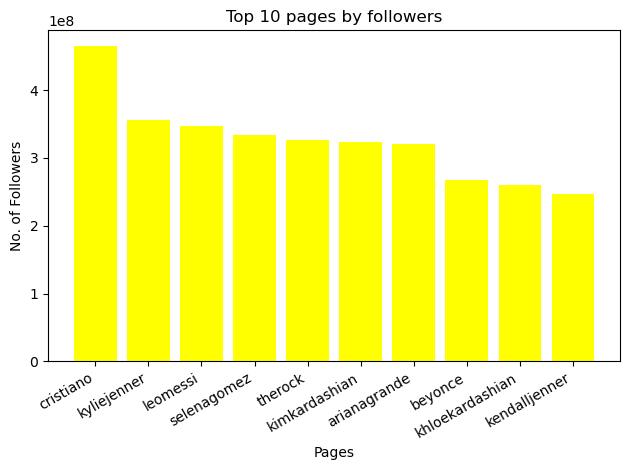

In [11]:
top_10_usernames = df.sort_values("Followers", ascending = False).head(10)
plt.bar(top_10_usernames["Channel Name"], top_10_usernames["Followers"], color = "yellow")
plt.xlabel("Pages")
plt.ylabel("No. of Followers")
plt.title("Top 10 pages by followers")
plt.xticks(rotation = 30, ha = "right")
plt.tight_layout()

The follower distribution among top Instagram pages is highly concentrated. A small set of celebrity accounts account for a disproportionately large share of followers, indicating a winner-takes-most pattern in social media popularity.
- Instagram follower growth at the top level is driven more by offline fame and global recognition than platform activity.

# Q2. Cateogry wise average followers

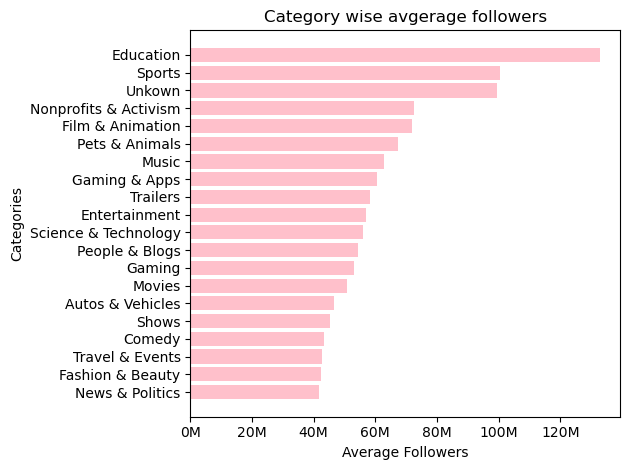

In [12]:
# Sorted the values to get a pattern
Avg_followers_mean = df.groupby("Main topic")["Followers"].mean()
avg_mean = Avg_followers_mean.sort_values()

plt.barh(avg_mean.index, avg_mean.values, color = "pink")
plt.xlabel("Average Followers")
plt.ylabel("Categories")
plt.title("Category wise avgerage followers")
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()

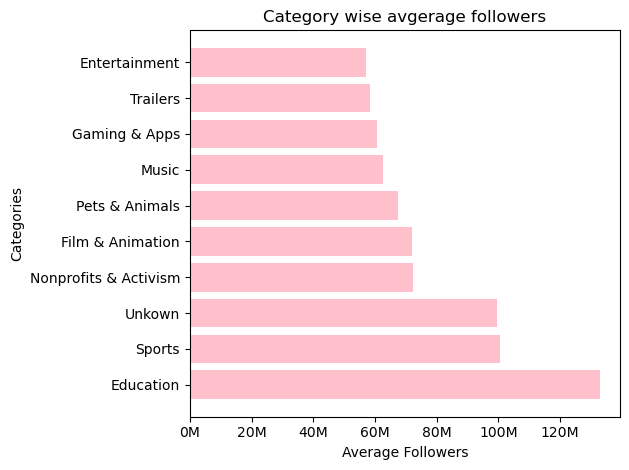

In [13]:
# Top 10 category wise average followers
top_mean = Avg_followers_mean.sort_values(ascending = False).head(10)

plt.barh(top_mean.index, top_mean.values, color = "pink")
plt.xlabel("Average Followers")
plt.ylabel("Categories")
plt.title("Category wise avgerage followers")
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()

Category-wise analysis shows significant variation in average followers across domains. Education and Sports categories have higher average follower counts, while categories such as Fashion & Beauty and News & Politics tend to have lower averages. This suggests that audience size and reach are strongly influenced by content domain.
- Content category matters — not all niches have equal audience potential.

# Q3. Relationship between posts and followers

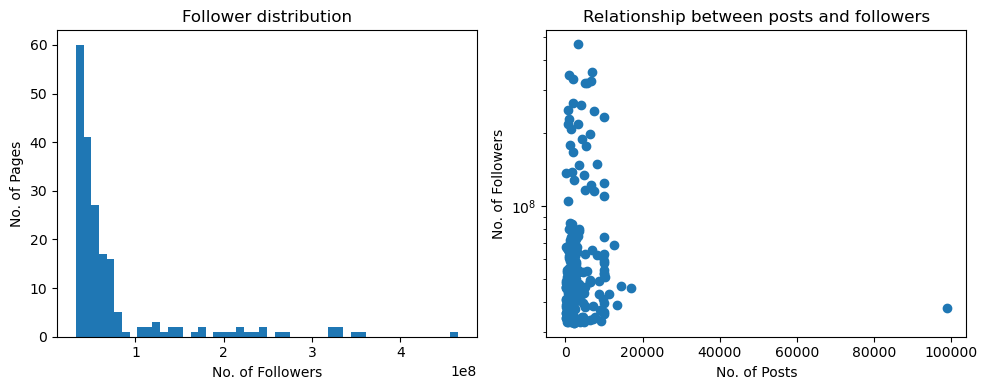

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].hist(df["Followers"], bins = 50)
axs[0].set_title("Follower distribution")
axs[0].set_xlabel("No. of Followers")
axs[0].set_ylabel("No. of Pages")

axs[1].scatter(x = df["Posts"], y = df["Followers"])
axs[1].set_yscale("log")
axs[1].set_xlabel("No. of Posts")
axs[1].set_ylabel("No. of Followers")
axs[1].set_title("Relationship between posts and followers")
plt.tight_layout()

##### Follower Distribution
The follower distribution is highly skewed, with most Instagram pages having low to moderate followers and a small number of pages having extremely high follower counts. This indicates a long-tail distribution common in social media platforms.
- Extreme popularity is rare, not the norm.

##### Overall Relationship Between Posts and Followers
The analysis shows no strong linear relationship between the number of posts and follower count. Several pages achieve high followers despite having relatively few posts, while many pages with a large number of posts have modest follower counts. This suggests that posting frequency alone does not determine popularity.
- Posting more is not sufficient for gaining followers.

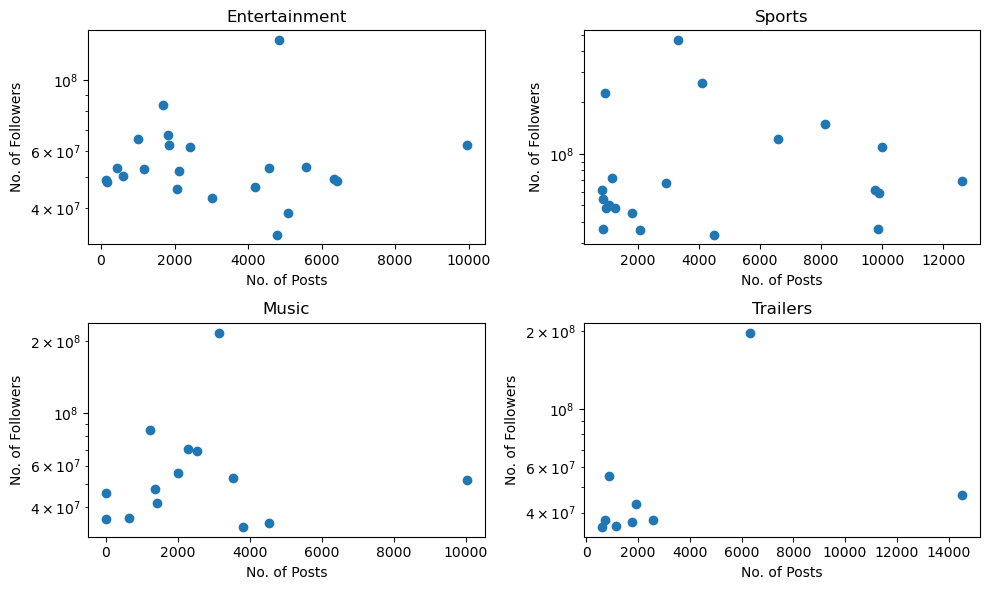

In [15]:
top_categories = ["Entertainment", "Sports", "Music", "Trailers"]
category_df = df[df["Main topic"].isin(top_categories)]

fig, axs = plt.subplots(2, 2, figsize=(10, 6))
axs = axs.flatten()
for i, cat in enumerate(top_categories):
    data = category_df[category_df["Main topic"] == cat]
    axs[i].scatter(data["Posts"], data["Followers"])
    axs[i].set_yscale("log")
    axs[i].set_xlabel("No. of Posts")
    axs[i].set_ylabel("No. of Followers")
    axs[i].set_title(cat)
plt.tight_layout()

Category-wise analysis reveals that the relationship between posts and followers varies across domains. Entertainment and Music categories achieve high follower counts with relatively fewer posts, while Sports and Trailers show wide variability with no clear trend. This indicates that category-specific factors such as popularity, brand recognition, and audience interest play a larger role than posting frequency.
- Context matters — the same strategy does not work across categories.

# Final Conclusion
Overall, the analysis demonstrates that Instagram follower growth is influenced more by content category, popularity, and audience interest than by posting frequency alone. While consistent posting is necessary, it is not sufficient to guarantee higher followers. Social media success follows a highly skewed distribution, where a small number of accounts dominate audience attention.